<a href="https://colab.research.google.com/github/Karsang-Chhombay-sherpa/AI-ML/blob/main/Road_Accident_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/dataset_traffic_accident_prediction1.csv")

In [ ]:
df.head(5)

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               798 non-null    object 
 1   Road_Type             798 non-null    object 
 2   Time_of_Day           798 non-null    object 
 3   Traffic_Density       798 non-null    float64
 4   Speed_Limit           798 non-null    float64
 5   Number_of_Vehicles    798 non-null    float64
 6   Driver_Alcohol        798 non-null    float64
 7   Accident_Severity     798 non-null    object 
 8   Road_Condition        798 non-null    object 
 9   Vehicle_Type          798 non-null    object 
 10  Driver_Age            798 non-null    float64
 11  Driver_Experience     798 non-null    float64
 12  Road_Light_Condition  798 non-null    object 
 13  Accident              798 non-null    float64
dtypes: float64(7), object(7)
memory usage: 92.0+ KB


In [ ]:
df.isnull().sum()

,0
Weather,42
Road_Type,42
Time_of_Day,42
Traffic_Density,42
Speed_Limit,42
Number_of_Vehicles,42
Driver_Alcohol,42
Accident_Severity,42
Road_Condition,42
Vehicle_Type,42


In [ ]:
df.columns

Index(['Weather', 'Road_Type', 'Time_of_Day', 'Traffic_Density', 'Speed_Limit',
       'Number_of_Vehicles', 'Driver_Alcohol', 'Accident_Severity',
       'Road_Condition', 'Vehicle_Type', 'Driver_Age', 'Driver_Experience',
       'Road_Light_Condition', 'Accident'],
      dtype='object')

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer =SimpleImputer(strategy="most_frequent")
df['Weather']=imputer.fit_transform(df[['Weather']]).ravel()

In [ ]:
df['Road_Type'].value_counts()

,count
Road_Type,
Highway,402
City Road,230
Rural Road,125
Mountain Road,41


In [ ]:
df['Road_Type']=imputer.fit_transform(df[['Road_Type']]).ravel()

In [ ]:
df["Time_of_Day"].value_counts()

,count
Time_of_Day,
Afternoon,272
Evening,218
Morning,201
Night,107


In [ ]:
df['Time_of_Day']=imputer.fit_transform(df[['Time_of_Day']]).ravel()

In [ ]:
df["Traffic_Density"].value_counts()

,count
Traffic_Density,
1.0,307
2.0,246
0.0,245


In [ ]:
df['Traffic_Density']=imputer.fit_transform(df[['Traffic_Density']]).ravel()

In [ ]:
df['Speed_Limit'].value_counts()

,count
Speed_Limit,
60.0,231
50.0,162
80.0,143
100.0,124
30.0,84
120.0,29
195.0,2
206.0,2
192.0,2


In [ ]:
median_speed=df['Speed_Limit'].median()
df['Speed_Limit']=df['Speed_Limit'].fillna(median_speed)

In [ ]:
df['Number_of_Vehicles'].value_counts()

,count
Number_of_Vehicles,
3.0,163
4.0,161
5.0,154
2.0,153
1.0,144
11.0,8
10.0,5
13.0,4
14.0,4


In [ ]:
median_Number_of_Vehicles=df['Number_of_Vehicles'].median()
df['Number_of_Vehicles']=df['Number_of_Vehicles'].fillna(median_Number_of_Vehicles)

In [ ]:
df['Driver_Alcohol'].value_counts()

,count
Driver_Alcohol,
0.0,670
1.0,128


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Driver_Alcohol', ylabel='Count'>

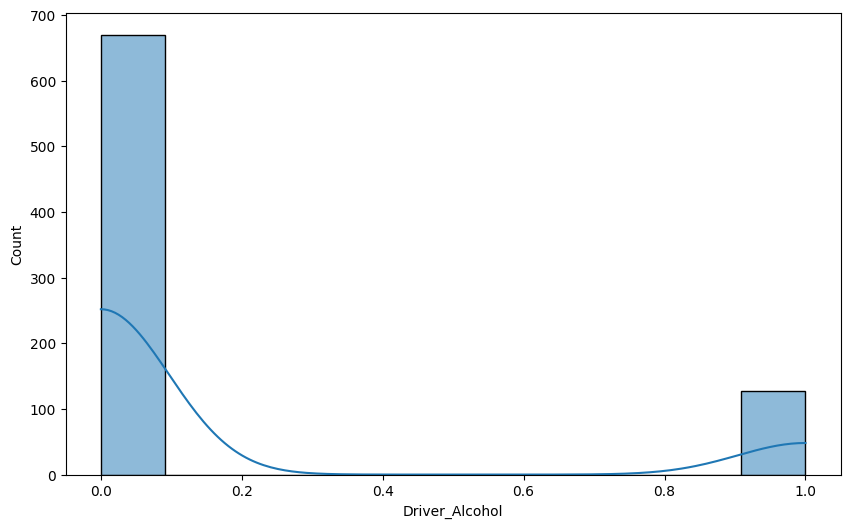

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Driver_Alcohol",kde=True)

In [ ]:
df.isnull().sum()

,0
Weather,0
Road_Type,0
Time_of_Day,0
Traffic_Density,0
Speed_Limit,0
Number_of_Vehicles,0
Driver_Alcohol,42
Accident_Severity,42
Road_Condition,42
Vehicle_Type,42


In [ ]:
Driver_Alcohol_mode=df['Driver_Alcohol'].mode()

df.loc[:, 'Driver_Alcohol']=df['Driver_Alcohol'].fillna(Driver_Alcohol_mode.iloc[0])

In [ ]:
df['Accident_Severity']
df['Accident_Severity']=imputer.fit_transform(df[['Accident_Severity']]).ravel()


In [ ]:
df['Road_Condition']=imputer.fit_transform(df[['Road_Condition']]).ravel()


In [ ]:
df['Vehicle_Type']=imputer.fit_transform(df[['Vehicle_Type']]).ravel()

In [ ]:
df['Driver_Age']

,Driver_Age
0,51.0
1,49.0
2,54.0
3,34.0
4,62.0
...,...
835,23.0
836,52.0
837,NaN
838,25.0


<Axes: xlabel='Driver_Age', ylabel='Count'>

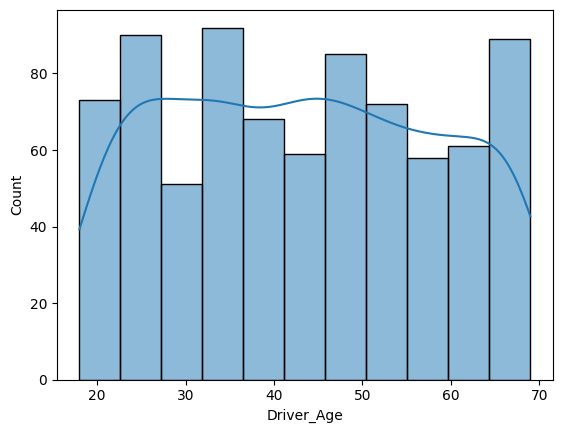

In [ ]:
sns.histplot(data=df,x='Driver_Age',kde=True)

In [ ]:
median_Driver_Age=df['Driver_Age'].median()
df['Driver_Age']=df['Driver_Age'].fillna(median_Driver_Age)

<Axes: xlabel='Driver_Experience', ylabel='Count'>

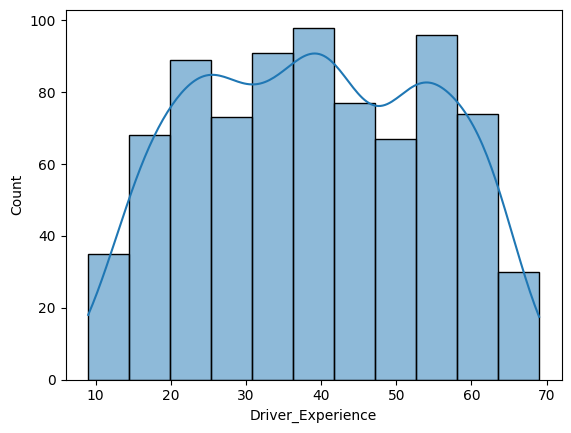

In [ ]:
df['Driver_Experience'].value_counts()
sns.histplot(data=df,x="Driver_Experience",kde=True)


In [ ]:
median_Drive_Experience=df['Driver_Experience'].median()
df['Driver_Experience']=df['Driver_Experience'].fillna(median_Drive_Experience)

In [ ]:
df['Road_Light_Condition'].value_counts()
df['Road_Light_Condition']=imputer.fit_transform(df[['Road_Light_Condition']]).ravel()

In [ ]:
df['Accident']=imputer.fit_transform(df[['Accident']]).ravel()

In [ ]:
df.isnull().sum()

,0
Weather,0
Road_Type,0
Time_of_Day,0
Traffic_Density,0
Speed_Limit,0
Number_of_Vehicles,0
Driver_Alcohol,0
Accident_Severity,0
Road_Condition,0
Vehicle_Type,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               840 non-null    object 
 1   Road_Type             840 non-null    object 
 2   Time_of_Day           840 non-null    object 
 3   Traffic_Density       840 non-null    float64
 4   Speed_Limit           840 non-null    float64
 5   Number_of_Vehicles    840 non-null    float64
 6   Driver_Alcohol        840 non-null    float64
 7   Accident_Severity     840 non-null    object 
 8   Road_Condition        840 non-null    object 
 9   Vehicle_Type          840 non-null    object 
 10  Driver_Age            840 non-null    float64
 11  Driver_Experience     840 non-null    float64
 12  Road_Light_Condition  840 non-null    object 
 13  Accident              840 non-null    float64
dtypes: float64(7), object(7)
memory usage: 92.0+ KB


In [ ]:
df.duplicated().sum()

np.int64(18)

In [ ]:
df.drop_duplicates()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,Low,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,1.0,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,Clear,Highway,Night,2.0,30.0,4.0,0.0,Low,Dry,Car,23.0,15.0,Daylight,0.0
836,Rainy,Rural Road,Evening,2.0,60.0,4.0,0.0,Low,Dry,Motorcycle,52.0,46.0,Daylight,1.0
837,Foggy,Highway,Evening,1.0,30.0,4.0,1.0,High,Dry,Car,43.0,34.0,Artificial Light,0.0
838,Foggy,Highway,Afternoon,2.0,60.0,3.0,0.0,Low,Dry,Car,25.0,19.0,Artificial Light,0.0


In [ ]:
df.dtypes

,0
Weather,object
Road_Type,object
Time_of_Day,object
Traffic_Density,float64
Speed_Limit,float64
Number_of_Vehicles,float64
Driver_Alcohol,float64
Accident_Severity,object
Road_Condition,object
Vehicle_Type,object


,count
Accident,
0.0,601
1.0,239
